Import Libraries

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import os

# ML models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Metrics
from sklearn.metrics import mean_squared_error, r2_score

# Save model
import joblib

Load Cleaned Dataset

In [3]:
df = pd.read_csv("../data/processed/car_data_clean.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel_Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller_Type         2059 non-null   object 
 11  Engine              2059 non-null   float64
 12  Max_Power           2059 non-null   float64
 13  Max_Torque          2059 non-null   float64
 14  Drivetrain          2059 non-null   object 
 15  Length              2059 non-null   float64
 16  Width 

Features and Target

In [4]:
# Target
y = df["Price"]

# Drop columns that are not so useful for prediction
drop_cols = ["Price", "Model", "Location", "Color"]

x = df.drop(columns=drop_cols)

# One-hot encode categorical features
x = pd.get_dummies(x, drop_first=True)

print("Feature matrix shape:", x.shape)

Feature matrix shape: (2059, 62)


Train and Test Split

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)

Train shape: (1647, 62) Test shape: (412, 62)


Linear Regression

In [9]:
lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression RMSE: {rmse_lr:.2f}")
print(f"Linear Regression R²: {r2_lr:.2f}")

Linear Regression RMSE: 1366168.34
Linear Regression R²: 0.73


Random Forest Regressor

In [10]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"Random Forest R²: {r2_rf:.2f}")

Random Forest RMSE: 1115418.28
Random Forest R²: 0.82


XGBoost Regressor

In [14]:
xgbr = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgbr.fit(x_train, y_train)

y_pred_xgb = xgbr.predict(x_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.2f}")
print(f"XGBoost R²: {r2_xgb:.2f}")

XGBoost RMSE: 879924.17
XGBoost R²: 0.89


Comapre Models

In [15]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R2_Score': [r2_lr, r2_rf, r2_xgb]
})
results

,Model,RMSE,R2_Score
0,Linear Regression,1.366168e+06,0.732846
1,Random Forest,1.115418e+06,0.821914
2,XGBoost,8.799242e+05,0.889173


Feature Importance (Random Forest)

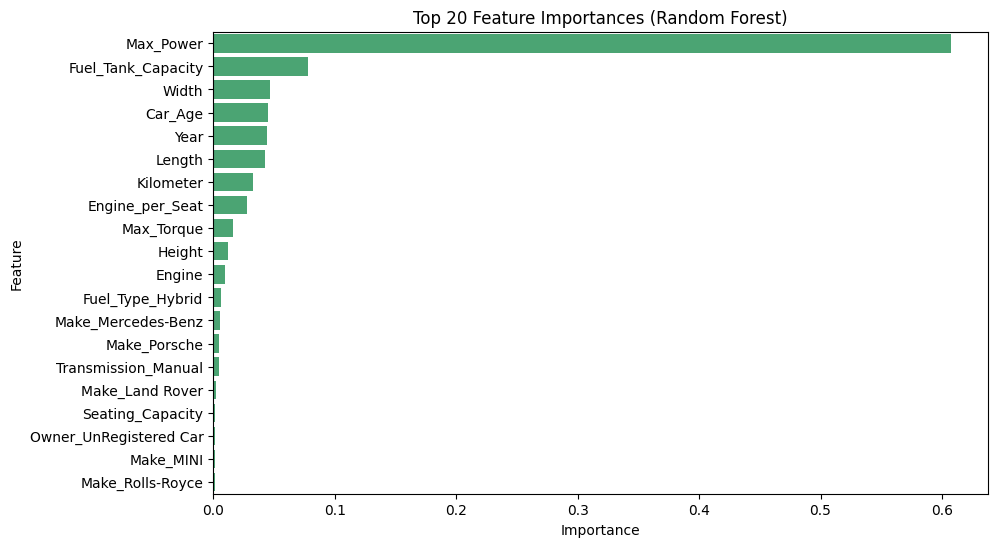

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

feat_imp = pd.Series(rf.feature_importances_, index=x.columns)
feat_imp = feat_imp.sort_values(ascending=False)[:20]  # top 20 features

plt.figure(figsize=(10,6))
sns.barplot(
    x=feat_imp.values,
    y=feat_imp.index,
    color='mediumseagreen'  # replace palette with single color
)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Save Best Model

In [19]:
# Create a dictionary of models and their RMSE
model_rmse = {
    'Linear Regression': rmse_lr,
    'Random Forest': rmse_rf,
    'XGBoost': rmse_xgb
}

# Find the model with the lowest RMSE
best_model_name = min(model_rmse, key=model_rmse.get)
print(f"Best Model: {best_model_name} with RMSE: {model_rmse[best_model_name]:.2f}")

# Select the corresponding model object
best_model = {'Linear Regression': lr, 'Random Forest': rf, 'XGBoost': xgbr}[best_model_name]

# Ensure models folder exists
os.makedirs('../models', exist_ok=True)

# Save the best model
joblib.dump(best_model, '../models/car_price_model.pkl')
print(f"Best model saved to '../models/car_price_model.pkl'")

Best Model: XGBoost with RMSE: 879924.17
Best model saved to '../models/car_price_model.pkl'
